# Getting objects out of `kshitijd/mmu-xmatch-5k`

Your crossmatched dataset has three kinds of files:

| File | What it is |
|---|---|
| `spine_selected.parquet` | **Start here.** The 5,000 objects: position, redshift, one True/False column per modality, `n_mod`, and `spine_id` (the join key for everything else) |
| `modalities/*.parquet` | The actual data payloads (spectra, images, light curves, labels), one file per source catalog, keyed by `spine_id` |
| `spine_full.parquet` | Bonus: the same modality flags for **all 20.4M** DESI DR1 anchors (no payloads) |

Recipe for everything below: **filter the spine → join a payload file on `spine_id`.**

In [1]:
import io, os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

REPO = "kshitijd/mmu-xmatch-5k"
# token: from HF_TOKEN env var, else grab it from the pipeline script
TOKEN = os.environ.get("HF_TOKEN") or re.search(
    r"hf_[A-Za-z0-9]{30,}", open("mmu_xmatch_5k.py").read()).group(0)

def get(fname):
    """Download one file from the dataset (cached after first call)."""
    return hf_hub_download(repo_id=REPO, repo_type="dataset",
                           filename=fname, token=TOKEN)

import pyarrow.parquet as pq

def load(fname, columns=None):
    """Read a dataset parquet safely (nested columns -> plain objects).
    Tip: pass columns=[...] to skip heavy array columns you don't need."""
    t = pq.read_table(get(fname), columns=columns)
    return t.to_pandas(ignore_metadata=True)

/home/me/Desktop/crossmatch/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the spine and look around

In [2]:
spine = load("spine_selected.parquet")
print(f"{len(spine)} objects, columns: {list(spine.columns)}")
spine.head(3)

5000 objects, columns: ['_healpix_29', 'ra', 'dec', 'TARGETID', 'Z', 'ZERR', 'ZWARN', 'ZCAT_PRIMARY', 'SPECTYPE', 'SURVEY', 'desi_z', 'desi_spec', 'vipers_spec', 'sdss_spec', 'gaia', 'hsc_img', 'chandra_xray', 'provabgs_lbl', 'gz10_lbl', 'legacy_img', 'tess_lc', 'ztf_alert', 'jwst_img', 'sn_lc', 'n_mod', 'spine_id', '__index_level_0__']


,_healpix_29,ra,dec,TARGETID,Z,ZERR,ZWARN,ZCAT_PRIMARY,SPECTYPE,SURVEY,...,provabgs_lbl,gz10_lbl,legacy_img,tess_lc,ztf_alert,jwst_img,sn_lc,n_mod,spine_id,__index_level_0__
0,643995010957798170,218.934005,35.076159,39632981379255428,0.028752,8.784728e-07,0,True,GALAXY,sv3,...,True,False,True,False,False,False,False,7,0,4260029
1,643995010957822661,218.933998,35.076164,2305843018806068695,0.028753,2.473378e-06,0,True,GALAXY,sv3,...,True,False,True,False,False,False,False,7,1,4260031
2,643995010957798218,218.934005,35.076159,43978251332224317,0.028769,1.696585e-06,0,True,GALAXY,special,...,True,False,True,False,False,False,False,7,2,4260030


In [3]:
# how many modalities does each object have?
print(spine["n_mod"].value_counts().sort_index())
# and how many objects have each modality?
flag_cols = [c for c in spine.columns if spine[c].dtype == bool]
print(spine[flag_cols].sum().sort_values(ascending=False))

n_mod
5    4807
6     184
7       9
Name: count, dtype: int64
ZCAT_PRIMARY    5000
desi_z          5000
desi_spec       4979
provabgs_lbl    4973
legacy_img      4545
sdss_spec       3344
hsc_img         1726
gz10_lbl         332
chandra_xray     112
gaia              70
ztf_alert         65
jwst_img          31
sn_lc             24
tess_lc            1
vipers_spec        0
dtype: int64


## 2. Pick objects

The flag columns are just booleans — combine them however you like.

In [4]:
# the 9 richest objects in the dataset (7 modalities each)
best = spine[spine.n_mod == 7]
best[["spine_id", "ra", "dec", "Z", "SPECTYPE", "n_mod"]]

,spine_id,ra,dec,Z,SPECTYPE,n_mod
0,0,218.934005,35.076159,0.028752,GALAXY,7
1,1,218.933998,35.076164,0.028753,GALAXY,7
2,2,218.934005,35.076159,0.028769,GALAXY,7
3,3,252.073042,35.900147,0.032249,GALAXY,7
4,4,217.629961,52.707159,0.044880,GALAXY,7
5,5,217.629927,52.707176,0.044912,GALAXY,7
6,6,242.035180,53.459843,0.065598,GALAXY,7
7,7,219.274970,34.633255,0.084074,GALAXY,7
8,8,217.415284,33.893498,0.130759,QSO,7


In [5]:
# example: X-ray detected objects that also have deep HSC imaging
xray_imaged = spine[spine.chandra_xray & spine.hsc_img]
print(f"{len(xray_imaged)} objects have Chandra X-ray + HSC imaging")
xray_imaged[["spine_id", "ra", "dec", "Z", "SPECTYPE"]].head()

7 objects have Chandra X-ray + HSC imaging


,spine_id,ra,dec,Z,SPECTYPE
177,177,243.417318,54.641309,0.229082,QSO
186,186,243.558808,54.714234,0.336975,GALAXY
189,189,149.704278,1.538828,0.363266,GALAXY
2727,2727,150.335966,2.433768,0.120992,GALAXY
4835,4835,240.310522,55.217789,0.214641,QSO


## 3. Physical labels

Three places to get ground-truth physical properties:

1. **The spine itself** — every object already carries `Z` (spectroscopic redshift), `ZERR`, and `SPECTYPE` (GALAXY / QSO / STAR).
2. **`modalities/desi_provabgs.parquet`** — 4,973 objects with Bayesian SED-fit properties: stellar mass, star-formation rate, age, metallicity.
3. **`modalities/desi_dr1_zcat.parquet`** — the full 136-column DESI DR1 measurement row for all 5,000.

In [6]:
# redshift + spectral class: already in the spine, all 5,000 objects
spine["SPECTYPE"].value_counts()

SPECTYPE
GALAXY    4961
QSO         36
STAR         3
Name: count, dtype: int64

In [7]:
# stellar mass, SFR, age, metallicity from PROVABGS
avail = pq.read_schema(get("modalities/desi_provabgs.parquet")).names
print("available columns:", [c for c in avail if c.isupper()][:12], "...")

label_cols = [c for c in ("LOG_MSTAR", "AVG_SFR", "TAGE_MW", "Z_MW", "Z_HP")
              if c in avail]
prov = load("modalities/desi_provabgs.parquet",
            columns=["spine_id"] + label_cols)   # skip the heavy MCMC chains
labels = spine.merge(prov[["spine_id"] + label_cols], on="spine_id", how="left")
labels[["spine_id", "Z", "SPECTYPE"] + label_cols].head()

available columns: ['PROVABGS_MCMC', 'PROVABGS_THETA_BF', 'LOG_MSTAR', 'Z_HP', 'Z_MW', 'TAGE_MW', 'AVG_SFR', 'ZERR', 'TSNR2_BGS', 'MAG_G', 'MAG_R', 'MAG_Z'] ...


,spine_id,Z,SPECTYPE,LOG_MSTAR,AVG_SFR,TAGE_MW,Z_MW,Z_HP
0,0,0.028752,GALAXY,10.711228,0.004163,9.371172,0.009108,0.028752
1,1,0.028753,GALAXY,10.711228,0.004163,9.371172,0.009108,0.028752
2,2,0.028769,GALAXY,10.711228,0.004163,9.371172,0.009108,0.028752
3,3,0.032249,GALAXY,11.043154,0.000165,7.995636,0.004381,0.032250
4,4,0.044880,GALAXY,11.019388,7.014349,8.026721,0.014641,0.044880


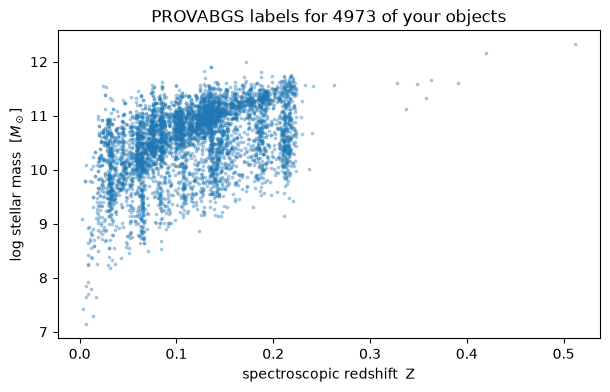

In [8]:
# the classic sanity plot: stellar mass vs redshift
ok = labels.dropna(subset=["LOG_MSTAR"])
plt.figure(figsize=(7, 4))
plt.scatter(ok["Z"], ok["LOG_MSTAR"], s=3, alpha=0.3)
plt.xlabel("spectroscopic redshift  Z"); plt.ylabel(r"log stellar mass  [$M_\odot$]")
plt.title(f"PROVABGS labels for {len(ok)} of your objects"); plt.show()

In [9]:
# every DESI DR1 measurement (136 columns) for all 5,000 objects
zcat = load("modalities/desi_dr1_zcat.parquet",
            columns=["spine_id", "Z", "ZERR", "SPECTYPE",
                     "DELTACHI2", "FLUX_G", "FLUX_R"])
zcat.head()

,spine_id,Z,ZERR,SPECTYPE,DELTACHI2,FLUX_G,FLUX_R
0,323,0.024656,0.000002,GALAXY,196599.928288,1098.944946,2142.881348
1,348,0.027142,0.000005,GALAXY,51268.764823,2128.669678,4231.707520
2,350,0.027164,0.000014,GALAXY,5110.501057,-99.000000,-99.000000
3,621,0.038058,0.000016,GALAXY,10850.853144,-99.000000,-99.000000
4,777,0.047873,0.000004,GALAXY,38447.599407,-99.000000,-99.000000


## 4. Get a spectrum

Payloads with arrays (spectra, light curves, images) store them as nested
columns. `nested-pandas` reads them back as little tables-within-cells.

(First call downloads the 375 MB spectra file once; cached afterwards.)

spectrum of spine_id=0: 7781 pixels, cols=['flux', 'ivar', 'lsf_sigma', 'lambda', 'mask']


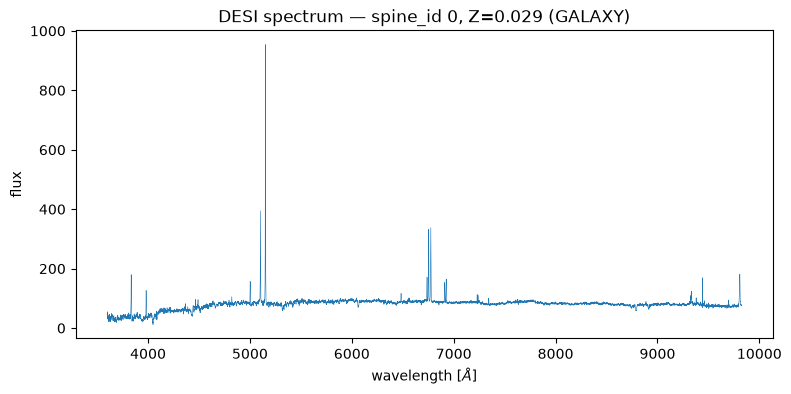

In [10]:
import nested_pandas as npd

spec = npd.read_parquet(get("modalities/desi_edr_sv3.parquet"))
target = best.iloc[0]                       # one of the 7-modality objects
row = spec[spec["spine_id"] == target.spine_id].iloc[0]
s = row["spectrum"]                          # a per-object table: flux/ivar/lambda...
print(f"spectrum of spine_id={target.spine_id}: {len(s)} pixels, cols={list(s.columns)}")

plt.figure(figsize=(9, 4))
plt.plot(s["lambda"], s["flux"], lw=0.4)
plt.xlabel(r"wavelength [$\AA$]"); plt.ylabel("flux")
plt.title(f"DESI spectrum — spine_id {target.spine_id}, Z={target.Z:.3f} ({target.SPECTYPE})")
plt.show()

## 5. Get an image

Same recipe. Galaxy Zoo rows carry an RGB cutout plus a human morphology label.

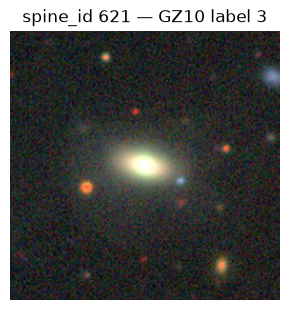

In [11]:
from PIL import Image

gz = load("modalities/gz10.parquet",
           columns=["spine_id", "gz10_label", "rgb_image"])
g = gz.iloc[0]
img = Image.open(io.BytesIO(g["rgb_image"]["bytes"]))
plt.figure(figsize=(3.5, 3.5)); plt.imshow(img); plt.axis("off")
plt.title(f"spine_id {g['spine_id']} — GZ10 label {g['gz10_label']}"); plt.show()

## Cheat sheet

| Spine flag | Payload file | What you get |
|---|---|---|
| (always) | `modalities/desi_dr1_zcat.parquet` | 136 DESI DR1 columns incl. Z, fluxes |
| `desi_spec` | `modalities/desi_edr_sv3.parquet` | DESI spectra (7,781 px) |
| `sdss_spec` | `modalities/sdss_sdss.parquet` | SDSS spectra |
| `provabgs_lbl` | `modalities/desi_provabgs.parquet` | mass, SFR, age, metallicity |
| `hsc_img` | `modalities/hsc_pdr3_dud_22.5.parquet` | 5-band deep cutouts (1.8 GB) |
| `legacy_img` | `modalities/ssl_legacysurvey_north.parquet` | Legacy cutouts (1.3 GB) |
| `gz10_lbl` | `modalities/gz10.parquet` | RGB image + morphology label |
| `chandra_xray` | `modalities/chandra_spectra.parquet` | X-ray spectra + fluxes |
| `gaia` | `modalities/gaia_gaia.parquet` | astrometry, XP coefficients |
| `ztf_alert` | `modalities/btsbot.parquet` | alert cutouts |
| `jwst_img` | `modalities/jwst_*.parquet` | JWST cutouts |
| `sn_lc` | `modalities/{yse_dr1,snls,...}.parquet` | supernova light curves |
| `tess_lc` | `modalities/tess_spoc.parquet` | TESS light curve |

Scaling up: `spine_full.parquet` (952 MB) has these same flags for **all
20,415,199** DR1 objects — same filtering recipe, 4,000× the sky.